# Class 11: The Multi-Armed Bandit Problem

Today we will:
- Play the **Bandit Game** (hands-on exploration-exploitation)
- Formalize the **multi-armed bandit** problem
- Implement and compare strategies: **random**, **greedy**, **epsilon-greedy**, **UCB**
- Connect bandits to **A/B testing**, **hyperparameter tuning**, and **online learning**

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Random seed for reproducibility
prng = np.random.RandomState(20260325)

## The Bandit Game (In-Class Activity)

We'll play the game first, then analyze the data and strategies afterward.

**Game link:** https://bandit-production.up.railway.app/

### Load Our Class Data

In [122]:
# Load exported game data
students_df = pd.read_csv('../data/bandit_game/students.csv')
actions_df = pd.read_csv('../data/bandit_game/actions.csv')
rewards_df = pd.read_csv('../data/bandit_game/rewards.csv')
rounds_df = pd.read_csv('../data/bandit_game/rounds.csv')
games_df = pd.read_csv('../data/bandit_game/games.csv')

def load_game_data(game_id):
    """Load and process student data for a given game."""
    game_rounds = rounds_df[rounds_df['game_id'] == game_id].copy()
    
    gd = (
        actions_df
        .merge(game_rounds[['id', 'round_number', 'prob_a', 'prob_b']], left_on='round_id', right_on='id', suffixes=('', '_round'))
        .merge(rewards_df, left_on='id', right_on='action_id')
        .merge(students_df[['id', 'name']], left_on='student_id', right_on='id', suffixes=('', '_student'))
    )
    
    gd['best_prob'] = gd[['prob_a', 'prob_b']].max(axis=1)
    gd['chosen_prob'] = np.where(gd['arm_selected'] == 'A', gd['prob_a'], gd['prob_b'])
    gd['regret'] = gd['best_prob'] - gd['chosen_prob']
    
    gd = gd.sort_values(['student_id', 'round_number'])
    
    gd['cum_regret'] = gd.groupby('student_id')['regret'].cumsum()
    gd['cum_reward'] = gd.groupby('student_id')['reward_value'].cumsum()
    
    return gd

def get_game_params(game_id):
    """Extract simulation parameters from the rounds table for a given game.
    Returns dict with probs per round, total rounds, and shift detection."""
    game_rounds = (
        rounds_df[rounds_df['game_id'] == game_id]
        .sort_values('round_number')
        .drop_duplicates('round_number')
        [['round_number', 'prob_a', 'prob_b']]
    )
    n_rounds = game_rounds['round_number'].max()
    
    # Detect probability changes: group consecutive rounds with same probs
    game_rounds['phase'] = (
        (game_rounds['prob_a'].diff().ne(0) | game_rounds['prob_b'].diff().ne(0))
        .cumsum()
    )
    phases = game_rounds.groupby('phase').agg(
        start=('round_number', 'min'),
        end=('round_number', 'max'),
        prob_a=('prob_a', 'first'),
        prob_b=('prob_b', 'first'),
    )
    
    is_stationary = len(phases) == 1
    
    if is_stationary:
        probs = [phases.iloc[0]['prob_a'], phases.iloc[0]['prob_b']]
        return {'n_rounds': n_rounds, 'probs': probs, 'stationary': True}
    else:
        early = phases.iloc[0]
        late = phases.iloc[1]
        shift_round = early['end']
        return {
            'n_rounds': n_rounds,
            'early_probs': [early['prob_a'], early['prob_b']],
            'late_probs': [late['prob_a'], late['prob_b']],
            'shift_round': int(shift_round),
            'stationary': False,
        }

# Scenario 1 (stationary) game data — change GAME_ID as needed
GAME_ID_STATIONARY = 2
game_data_short = load_game_data(GAME_ID_STATIONARY)
params_s1 = get_game_params(GAME_ID_STATIONARY)

probs = params_s1['probs']
n_rounds_short = params_s1['n_rounds']

print(f"Stationary game {GAME_ID_STATIONARY}: {game_data_short['name'].nunique()} students, {n_rounds_short} rounds")
print(f"  Arm probabilities: A={probs[0]}, B={probs[1]}")
game_data_short[['name', 'round_number', 'arm_selected', 'reward_value', 'regret', 'cum_regret']].head(10)

Stationary game 2: 6 students, 20 rounds
  Arm probabilities: A=0.3, B=0.7


,name,round_number,arm_selected,reward_value,regret,cum_regret
40,x,1,B,1.0,0.0,0.0
41,x,2,B,0.0,0.0,0.0
42,x,3,B,0.0,0.0,0.0
43,x,4,B,1.0,0.0,0.0
44,x,5,A,1.0,0.4,0.4
45,x,6,A,1.0,0.4,0.8
46,x,7,B,0.0,0.0,0.8
47,x,8,A,0.0,0.4,1.2
48,x,9,B,0.0,0.0,1.2
49,x,10,B,1.0,0.0,1.2


## Formalizing the Problem

### The multi-armed bandit

- **K arms** (options/actions), each with unknown reward probability $p_k$
- At each round $t$, you choose one arm and observe a reward (0 or 1)
- **Goal:** maximize total reward over $T$ rounds

### Regret

The quality of a strategy is measured by **regret** — how much worse you did compared to always playing the best arm:

$$\text{Regret}(T) = T \cdot p^* - \sum_{t=1}^{T} p_{a_t}$$

where $p^* = \max_k p_k$ is the best arm's probability and $a_t$ is the arm chosen at round $t$.

- **Perfect strategy**: regret = 0 (always play the best arm — but you don't know which it is!)
- **Random strategy**: regret grows linearly with $T$
- **Good strategies**: regret grows as $O(\log T)$ — sublinear!

## Implementing Bandit Strategies

### The Bernoulli bandit environment

- Each arm pays out 1 with probability $p_k$ and 0 otherwise
- This matches our game exactly

In [123]:
class BernoulliBandit:
    """K-armed Bernoulli bandit."""
    
    def __init__(self, probabilities, rng=None):
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.best_arm = np.argmax(probabilities)
        self.best_prob = probabilities[self.best_arm]
        self.rng = rng or np.random.RandomState()
    
    def pull(self, arm):
        """Pull an arm, get reward 0 or 1."""
        return 1.0 if self.rng.random() < self.probabilities[arm] else 0.0
    
    def regret(self, arm):
        """Instantaneous regret of choosing this arm."""
        return self.best_prob - self.probabilities[arm]

### Strategy 1: Random (baseline)

- Pick a random arm each round
- No learning at all
- Regret grows linearly

In [28]:
class RandomAgent:
    """Picks a random arm every round."""
    
    def __init__(self, k, rng=None):
        self.k = k
        self.rng = rng or np.random.RandomState()
    
    def choose(self):
        return self.rng.randint(self.k)
    
    def update(self, arm, reward):
        pass  # no learning

### Strategy 2: Greedy (pure exploitation)

- Track the average reward for each arm
- Always pick the arm with the highest average
- **Problem:** can lock onto a suboptimal arm after a few unlucky initial pulls

In [29]:
class GreedyAgent:
    """Always picks the arm with the highest observed average."""
    
    def __init__(self, k, rng=None):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
        self.rng = rng or np.random.RandomState()
    
    def choose(self):
        # Try each arm once first
        untried = np.where(self.counts == 0)[0]
        if len(untried) > 0:
            return untried[0]
        return np.argmax(self.values)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        # Incremental mean update: new_avg = old_avg + (reward - old_avg) / n
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

### Strategy 3: Epsilon-greedy (simple exploration)

- With probability $\varepsilon$: explore (random arm)
- With probability $1 - \varepsilon$: exploit (best arm so far)
- **Trade-off knob:** $\varepsilon$ controls how much you explore
- Common values: $\varepsilon = 0.1$ (explore 10% of the time)

In [30]:
class EpsilonGreedyAgent:
    """Explore with probability epsilon, exploit otherwise."""
    
    def __init__(self, k, epsilon=0.1, rng=None):
        self.k = k
        self.epsilon = epsilon
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
        self.rng = rng or np.random.RandomState()
    
    def choose(self):
        # Try each arm once first
        untried = np.where(self.counts == 0)[0]
        if len(untried) > 0:
            return untried[0]
        
        if self.rng.random() < self.epsilon:
            return self.rng.randint(self.k)  # explore
        else:
            return np.argmax(self.values)  # exploit
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

### Strategy 4: Upper Confidence Bound (UCB)

- **Key idea:** "Optimism in the face of uncertainty"
- Pick the arm with the highest *upper confidence bound*, not just the highest average
- UCB score for arm $k$ at round $t$:

$$\text{UCB}_k(t) = \hat{\mu}_k + c \cdot \sqrt{\frac{\ln t}{N_k(t)}}$$

- $\hat{\mu}_k$ = observed average reward of arm $k$
- $N_k(t)$ = number of times arm $k$ has been pulled
- The exploration bonus $\sqrt{\frac{\ln t}{N_k(t)}}$ is large for rarely-tried arms
- $c$ controls exploration intensity (we use $c = 0.5$; more on this later)
- **Key advantage over epsilon-greedy:** explores *where it's uncertain*, not randomly

In [31]:
class UCBAgent:
    """Upper Confidence Bound strategy."""
    
    def __init__(self, k, c=0.5, rng=None):
        self.k = k
        self.c = c
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
        self.t = 0
        self.rng = rng or np.random.RandomState()
    
    def choose(self):
        self.t += 1
        # Try each arm once first
        untried = np.where(self.counts == 0)[0]
        if len(untried) > 0:
            return untried[0]
        
        ucb_values = self.values + self.c * np.sqrt(np.log(self.t) / self.counts)
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

## Simulation for Comparing Strategies

### Scenario 1: Stationary bandit

- Arm A: 30%, Arm B: 70%
- Short horizon — luck matters a lot
- We'll later look at longer horizons to see how strategies diverge

In [91]:
def run_simulation(bandit, agent, n_rounds):
    """Run one episode: agent plays bandit for n_rounds.
    Returns arrays of rewards and cumulative regrets."""
    rewards = np.zeros(n_rounds)
    regrets = np.zeros(n_rounds)
    arms_chosen = np.zeros(n_rounds, dtype=int)
    
    for t in range(n_rounds):
        arm = agent.choose()
        reward = bandit.pull(arm)
        agent.update(arm, reward)
        
        rewards[t] = reward
        regrets[t] = bandit.regret(arm)
        arms_chosen[t] = arm
    
    return rewards, np.cumsum(regrets), arms_chosen


def run_monte_carlo(bandit_probs, agent_class, agent_kwargs, n_rounds, n_sims=1000, seed=42):
    """Run many simulations, return average cumulative regret."""
    all_cum_regrets = np.zeros((n_sims, n_rounds))
    all_rewards = np.zeros((n_sims, n_rounds))
    
    for i in range(n_sims):
        rng = np.random.RandomState(seed + i)
        bandit = BernoulliBandit(bandit_probs, rng=rng)
        agent = agent_class(k=len(bandit_probs), rng=rng, **agent_kwargs)
        rewards, cum_regret, _ = run_simulation(bandit, agent, n_rounds)
        all_cum_regrets[i] = cum_regret
        all_rewards[i] = rewards
    
    return all_cum_regrets, all_rewards

In [124]:
# Scenario 1: Stationary bandit — probs and n_rounds_short from game data above
n_sims = 2000

strategies = {
    'Random': (RandomAgent, {}),
    'Greedy': (GreedyAgent, {}),
    'Epsilon-Greedy (0.1)': (EpsilonGreedyAgent, {'epsilon': 0.1}),
    'UCB (c=0.5)': (UCBAgent, {}),
}

results_short = {}
for name, (agent_cls, kwargs) in strategies.items():
    cum_regrets, rewards = run_monte_carlo(probs, agent_cls, kwargs, n_rounds_short, n_sims)
    total_rewards = rewards.sum(axis=1)
    results_short[name] = {
        'cum_regret_mean': cum_regrets.mean(axis=0),
        'cum_regret_std': cum_regrets.std(axis=0),
        'total_reward_mean': total_rewards.mean(),
        'total_reward_p5': np.percentile(total_rewards, 5),
        'final_regret_mean': cum_regrets[:, -1].mean(),
    }

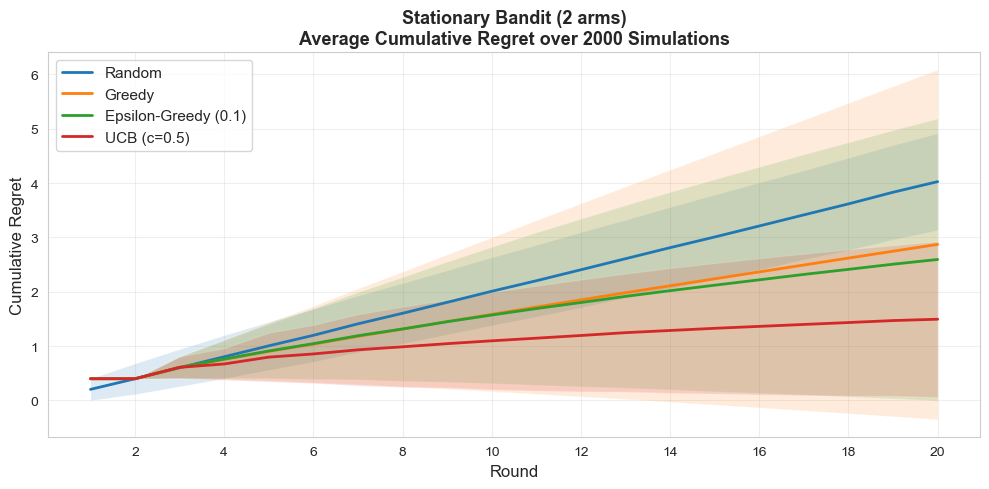

In [126]:
# Plot cumulative regret — short horizon
fig, ax = plt.subplots(figsize=(10, 5))

for name, res in results_short.items():
    rounds = np.arange(1, n_rounds_short + 1)
    ax.plot(rounds, res['cum_regret_mean'], label=name, linewidth=2)
    ax.fill_between(rounds, 
                    res['cum_regret_mean'] - res['cum_regret_std'],
                    res['cum_regret_mean'] + res['cum_regret_std'],
                    alpha=0.15)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title('Stationary Bandit (2 arms)\nAverage Cumulative Regret over 2000 Simulations', fontsize=13, fontweight='bold')
ax.set_xticks(np.arange(2, n_rounds_short + 1, 2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
# Summary table — short horizon
summary_short = pd.DataFrame({
    'Strategy': list(results_short.keys()),
    'Avg Total Reward': [r['total_reward_mean'] for r in results_short.values()],
    'Worst 5% Reward': [r['total_reward_p5'] for r in results_short.values()],
    'Avg Final Regret': [r['final_regret_mean'] for r in results_short.values()],
}).set_index('Strategy')

summary_short

,Avg Total Reward,Worst 5% Reward,Avg Final Regret
Strategy,,,
Random,9.925,6.0,4.027
Greedy,11.161,4.0,2.872
Epsilon-Greedy (0.1),11.427,5.0,2.595
UCB (c=0.5),12.528,8.0,1.495


- With only a few rounds, differences between strategies are small — luck plays a big role
- UCB already edges ahead by exploring efficiently even in this short horizon

### How did you compare to the algorithms?

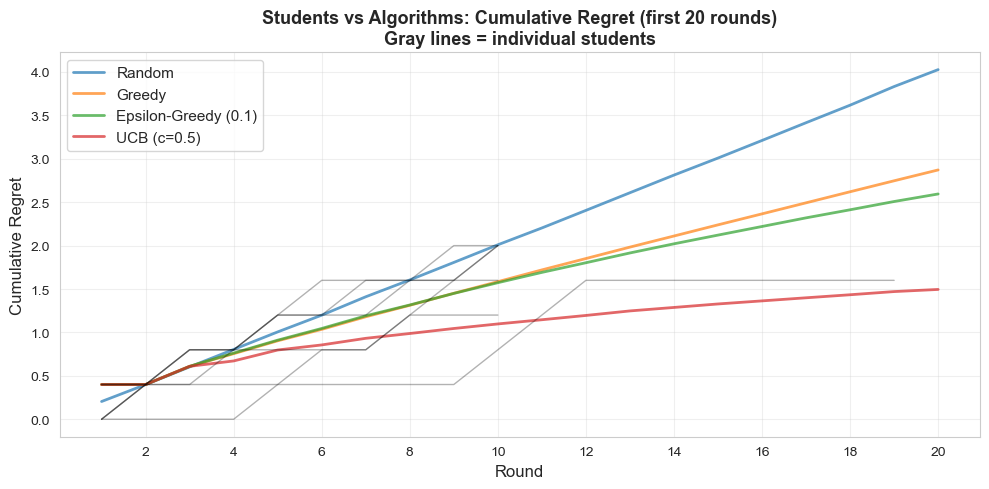

In [128]:
# Overlay: algorithm average regret + individual student traces
fig, ax = plt.subplots(figsize=(10, 5))

# Algorithm curves
for name, res in results_short.items():
    rounds = np.arange(1, n_rounds_short + 1)
    ax.plot(rounds, res['cum_regret_mean'], label=name, linewidth=2, alpha=0.7)

# Student traces (no legend, no markers, high transparency)
for sname, grp in game_data_short.groupby('name'):
    ax.plot(grp['round_number'].values, grp['cum_regret'].values,
            linewidth=1, alpha=0.3, color='black')

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title(f'Students vs Algorithms: Cumulative Regret (first {n_rounds_short} rounds)\nGray lines = individual students',
             fontsize=13, fontweight='bold')
ax.set_xticks(np.arange(2, n_rounds_short + 1, 2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
# Summary table: algorithms + class average
student_total_rewards = game_data_short.groupby('student_id')['reward_value'].sum()
student_final_regrets = game_data_short.groupby('student_id')['cum_regret'].last()

class_avg = {
    'Avg Total Reward': student_total_rewards.mean(),
    'Worst 5% Reward': np.percentile(student_total_rewards, 5),
    'Avg Final Regret': student_final_regrets.mean(),
}

summary_compare = summary_short.copy()
summary_compare.loc['Students (class avg)'] = class_avg
summary_compare

,Avg Total Reward,Worst 5% Reward,Avg Final Regret
Strategy,,,
Random,9.925,6.00,4.027
Greedy,11.161,4.00,2.872
Epsilon-Greedy (0.1),11.427,5.00,2.595
UCB (c=0.5),12.528,8.00,1.495
Students (class avg),4.000,2.25,1.733


### Visualizing arm selection over time

- How quickly does each strategy converge to the best arm?

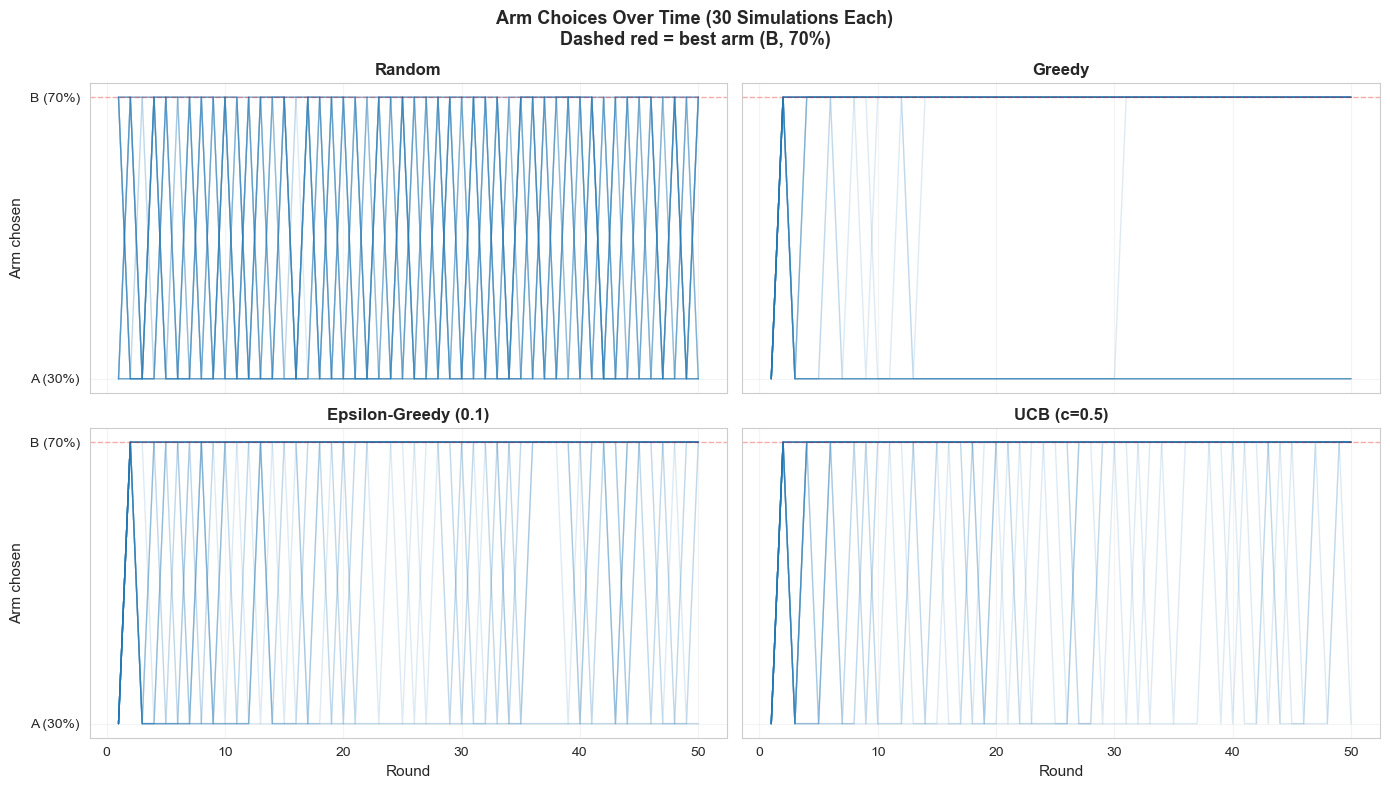

In [130]:
# Visualize individual simulation traces: which arm is chosen each round?
n_rounds_trace = 50
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

arm_labels = ['A (30%)', 'B (70%)']
n_trace_sims = 30  # enough to see patterns, not too cluttered

for idx, (name, (agent_cls, kwargs)) in enumerate(strategies.items()):
    ax = axes.flat[idx]
    
    for sim in range(n_trace_sims):
        rng = np.random.RandomState(42 + sim)
        bandit = BernoulliBandit(probs, rng=rng)
        agent = agent_cls(k=len(probs), rng=rng, **kwargs)
        _, _, arms = run_simulation(bandit, agent, n_rounds_trace)
        
        rounds = np.arange(1, n_rounds_trace + 1)
        ax.plot(rounds, arms, alpha=0.15, linewidth=1, color='C0')
    
    ax.set_yticks(range(len(arm_labels)))
    ax.set_yticklabels(arm_labels)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.3, linewidth=1)  # best arm = B
    if idx >= 2:
        ax.set_xlabel('Round', fontsize=11)
    if idx % 2 == 0:
        ax.set_ylabel('Arm chosen', fontsize=11)
    ax.grid(True, alpha=0.2)

fig.suptitle('Arm Choices Over Time (30 Simulations Each)\nDashed red = best arm (B, 70%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- **Random**: flips between A and B every round — no learning
- **Greedy**: locks in early — usually on B, but some simulations get stuck on A permanently after an unlucky first pull
- **Epsilon-greedy**: mostly B, but keeps flipping to A (the 10% random exploration is visible)
- **UCB**: tries both arms early, then commits to B — targeted exploration, then exploitation

### Long-run behavior: 1000 rounds

- With a longer horizon, differences between strategies become dramatic
- Good strategies have sublinear regret: $O(\log T)$

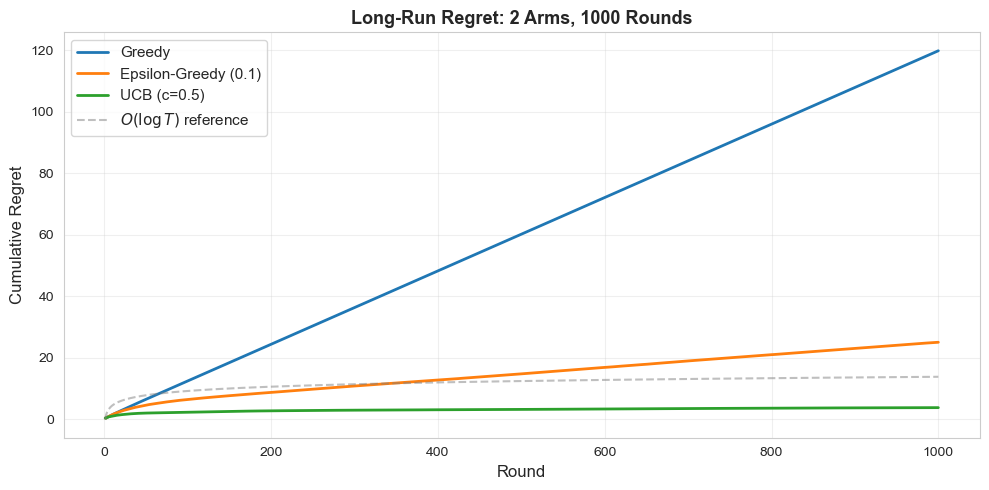

In [132]:
# Extended simulation: 1000 rounds (excluding Random — it just grows linearly)
n_rounds_long = 1000

strategies_no_random = {k: v for k, v in strategies.items() if k != 'Random'}

results_long = {}
for name, (agent_cls, kwargs) in strategies_no_random.items():
    cum_regrets, rewards = run_monte_carlo(probs, agent_cls, kwargs, n_rounds_long, n_sims=500)
    results_long[name] = {
        'cum_regret_mean': cum_regrets.mean(axis=0),
    }

fig, ax = plt.subplots(figsize=(10, 5))

for name, res in results_long.items():
    rounds = np.arange(1, n_rounds_long + 1)
    ax.plot(rounds, res['cum_regret_mean'], label=name, linewidth=2)

# Add O(log T) reference line
log_ref = 2 * np.log(np.arange(1, n_rounds_long + 1))
ax.plot(rounds, log_ref, '--', color='gray', alpha=0.5, label=r'$O(\log T)$ reference')

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title('Long-Run Regret: 2 Arms, 1000 Rounds',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **Greedy**: linear regret — it gets stuck on a suboptimal arm and never recovers
- **Epsilon-greedy**: sublinear, but the constant 10% random exploration adds up over time
- **UCB**: near-optimal $O(\log T)$ regret — explores less as confidence grows, concentrates on the best arm

Both epsilon-greedy and UCB have a hyperparameter that controls exploration. But while epsilon-greedy explored blindly (at fixed rate forever), UCB explores intelligently (adjusting for the uncertainty).

## Non-Stationary Bandits (Scenario 2)

- What happens when the environment changes?
- The arm probabilities **swap** partway through the game
- Pure exploitation after the shift → catastrophic failure

In [133]:
class NonStationaryBandit:
    """Bandit where probabilities change at a shift point."""
    
    def __init__(self, early_probs, late_probs, shift_round, rng=None):
        self.early_probs = np.array(early_probs)
        self.late_probs = np.array(late_probs)
        self.shift_round = shift_round
        self.k = len(early_probs)
        self.rng = rng or np.random.RandomState()
        self.current_round = 0
    
    @property
    def probabilities(self):
        if self.current_round <= self.shift_round:
            return self.early_probs
        return self.late_probs
    
    @property
    def best_prob(self):
        return np.max(self.probabilities)
    
    def pull(self, arm):
        self.current_round += 1
        return 1.0 if self.rng.random() < self.probabilities[arm] else 0.0
    
    def regret(self, arm):
        return self.best_prob - self.probabilities[arm]

In [ ]:
# Scenario 2 (non-stationary) game data — change GAME_ID as needed
GAME_ID_NS = 2  # TODO: set to the non-stationary game ID
game_data_ns = load_game_data(GAME_ID_NS)
params_ns = get_game_params(GAME_ID_NS)

if params_ns['stationary']:
    # Game is stationary — set NS simulation params manually
    print(f"⚠ Game {GAME_ID_NS} is stationary (A={params_ns['probs'][0]}, B={params_ns['probs'][1]})")
    print("  Using manual non-stationary params for simulation")
    early_probs = [0.7, 0.3]
    late_probs = [0.3, 0.7]
    shift_round = params_ns['n_rounds'] // 2
    n_rounds_ns = params_ns['n_rounds']
else:
    early_probs = params_ns['early_probs']
    late_probs = params_ns['late_probs']
    shift_round = params_ns['shift_round']
    n_rounds_ns = params_ns['n_rounds']
    print(f"Non-stationary game {GAME_ID_NS}: {game_data_ns['name'].nunique()} students, {n_rounds_ns} rounds")
    print(f"  Rounds 1-{shift_round}: A={early_probs[0]}, B={early_probs[1]}")
    print(f"  Rounds {shift_round+1}-{n_rounds_ns}: A={late_probs[0]}, B={late_probs[1]}")

In [ ]:
# Run non-stationary simulation — params from game data above
n_sims_ns = 2000

results_ns = {}

for name, (agent_cls, kwargs) in strategies.items():
    all_cum_regrets = np.zeros((n_sims_ns, n_rounds_ns))
    all_rewards = np.zeros((n_sims_ns, n_rounds_ns))

    for i in range(n_sims_ns):
        rng = np.random.RandomState(42 + i)
        bandit = NonStationaryBandit(early_probs, late_probs, shift_round, rng=rng)
        agent = agent_cls(k=2, rng=rng, **kwargs)

        regrets = np.zeros(n_rounds_ns)
        rewards = np.zeros(n_rounds_ns)
        for t in range(n_rounds_ns):
            arm = agent.choose()
            reward = bandit.pull(arm)
            reg = bandit.regret(arm)
            agent.update(arm, reward)
            regrets[t] = reg
            rewards[t] = reward

        all_cum_regrets[i] = np.cumsum(regrets)
        all_rewards[i] = rewards

    total_rewards = all_rewards.sum(axis=1)
    results_ns[name] = {
        'cum_regret_mean': all_cum_regrets.mean(axis=0),
        'final_regret_mean': all_cum_regrets[:, -1].mean(),
        'total_reward_mean': total_rewards.mean(),
        'total_reward_p5': np.percentile(total_rewards, 5),
    }

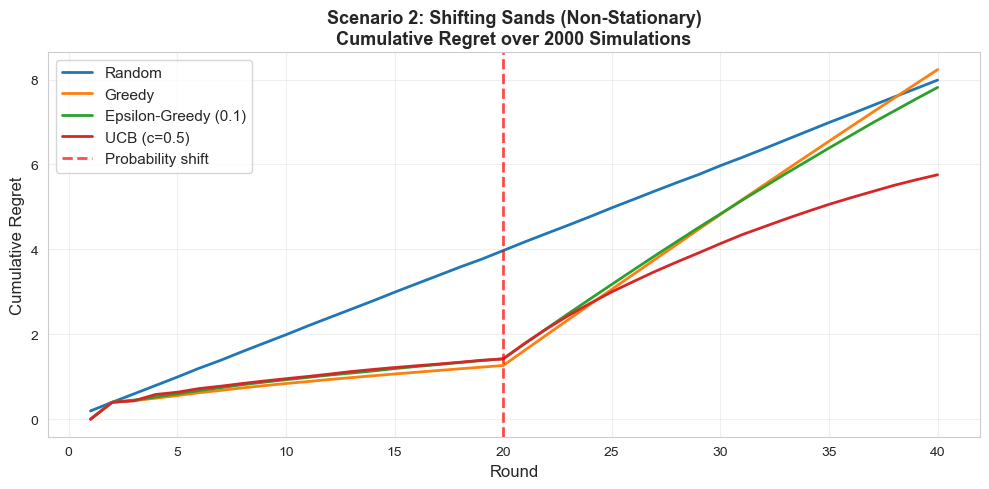

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, res in results_ns.items():
    rounds = np.arange(1, n_rounds_ns + 1)
    ax.plot(rounds, res['cum_regret_mean'], label=name, linewidth=2)

ax.axvline(x=shift_round, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Probability shift')
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title('Scenario 2: Shifting Sands (Non-Stationary)\nCumulative Regret over 2000 Simulations', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- After the shift (red line), regret accumulates faster for strategies that don't re-explore
- **Greedy** is worst: fully committed to arm A, no mechanism to detect that B is now better
- **Epsilon-greedy**: continuous 10% random exploration helps detect the shift — it eventually discovers B's new higher payoff
- **UCB**: the exploration bonus naturally grows for arm B (not recently pulled), helping it adapt
- **Lesson**: In non-stationary environments, you must *never stop exploring*

### How did you compare to the algorithms? (Non-stationary)

In [ ]:
# Overlay: algorithm NS regret + individual student traces
fig, ax = plt.subplots(figsize=(10, 5))

# Algorithm curves
for name, res in results_ns.items():
    rounds = np.arange(1, n_rounds_ns + 1)
    ax.plot(rounds, res['cum_regret_mean'], label=name, linewidth=2, alpha=0.7)

# Student traces (no legend, no markers, high transparency)
for sname, grp in game_data_ns.groupby('name'):
    ax.plot(grp['round_number'].values, grp['cum_regret'].values,
            linewidth=1, alpha=0.3, color='black')

ax.axvline(x=shift_round, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Probability shift')
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title(f'Students vs Algorithms: Non-Stationary (first {n_rounds_ns} rounds)\nGray lines = individual students',
             fontsize=13, fontweight='bold')
ax.set_xticks(np.arange(2, n_rounds_ns + 1, 2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: NS algorithms + class average
summary_ns = pd.DataFrame({
    'Strategy': list(results_ns.keys()),
    'Avg Total Reward': [r['total_reward_mean'] for r in results_ns.values()],
    'Worst 5% Reward': [r['total_reward_p5'] for r in results_ns.values()],
    'Avg Final Regret': [r['final_regret_mean'] for r in results_ns.values()],
}).set_index('Strategy')

student_total_rewards_ns = game_data_ns.groupby('student_id')['reward_value'].sum()
student_final_regrets_ns = game_data_ns.groupby('student_id')['cum_regret'].last()

class_avg_ns = {
    'Avg Total Reward': student_total_rewards_ns.mean(),
    'Worst 5% Reward': np.percentile(student_total_rewards_ns, 5),
    'Avg Final Regret': student_final_regrets_ns.mean(),
}

summary_compare_ns = summary_ns.copy()
summary_compare_ns.loc['Students (class avg)'] = class_avg_ns
summary_compare_ns

## Connections to Machine Learning

### Where do bandits show up in practice?

| Application | Arms | Reward | Why not just A/B test? |
|-------------|------|--------|------------------------|
| **A/B testing** | Website variants | Click/conversion | Bandits adapt *during* the test, reducing opportunity cost |
| **Recommendation** | Items to show | User engagement | Too many items to test all equally |
| **Hyperparameter tuning** | HP configurations | Model accuracy | Bayesian optimization = sophisticated bandit |
| **Clinical trials** | Treatments | Patient outcome | Ethical: don't keep giving inferior treatment |
| **Ad placement** | Ad variants | Click-through rate | Millions of impressions = real money lost on bad ads |

### Connection to the rest of the course

- **Bias-variance (Class 4)**: Epsilon is like a regularization parameter — explore too much = high variance, too little = high bias
- **Cross-validation (Class 5)**: CV tries all models on held-out data — similar exploration spirit
- **Neural networks (Classes 9-10)**: SGD explores the loss landscape — learning rate is like epsilon

## From Bandits to Reinforcement Learning

### Can a neural network learn to play the bandit?

Instead of hand-coded rules (greedy, UCB), what if we let a neural network learn which arm to pull?

**Simplest setup:** A network with **no real inputs**, just a single `Dense` layer that outputs a probability for each arm — the exact same Keras building blocks from Class 9! We train it by reinforcing actions that got high rewards.

**Key difference from Class 9:** there we trained on a full dataset at once (`model.fit`). Here the network learns **one step at a time** — it pulls an arm, observes the reward, and updates. This is the core idea of **policy gradient** methods in reinforcement learning.

In [143]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the bandit "brain" — same Keras pattern as Class 9!
# No real input features: we feed a dummy "1" and the Dense layer learns
# which arm is best (its weights ARE the arm preferences).

class NNBanditAgent:
    """Neural network that learns arm preferences from rewards (policy gradient)."""
    
    def __init__(self, k, lr=0.5, rng=None):
        self.k = k
        self.rng = rng or np.random.RandomState()
        
        # Build the model (same pattern as Class 9)
        # Zero-init so softmax starts at uniform (0.5, 0.5) — no prior bias
        self.model = keras.Sequential([
            layers.Input(shape=(1,)),
            layers.Dense(k, activation='softmax', kernel_initializer='zeros')
        ])
        
        self.optimizer = tf.keras.optimizers.SGD(learning_rate=lr)
        # Dummy input: always feed [1.0] -> the Dense layer's weights are the arm logits
        self.dummy_input = tf.constant([[1.0]])
    
    def choose(self):
        """Sample an arm from the learned probability distribution."""
        probs = self.model(self.dummy_input).numpy()[0]
        return self.rng.choice(self.k, p=probs)
    
    def update(self, arm, reward):
        """Policy gradient: reinforce the chosen arm proportional to reward."""
        with tf.GradientTape() as tape:
            probs = self.model(self.dummy_input)
            log_prob = tf.math.log(probs[0, arm] + 1e-10)
            # High reward -> push chosen arm's probability UP
            # Low/zero reward -> push it DOWN (relative to others)
            loss = -reward * log_prob
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

In [146]:
# Let's look at the model
probs_nn = [0.3, 0.7]
n_rounds_nn = 50

rng = np.random.RandomState(20260325)
bandit = BernoulliBandit(probs_nn, rng=rng)
agent = NNBanditAgent(k=len(probs_nn), lr=0.5, rng=rng)

# Same model.summary() we used in Class 9
agent.model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

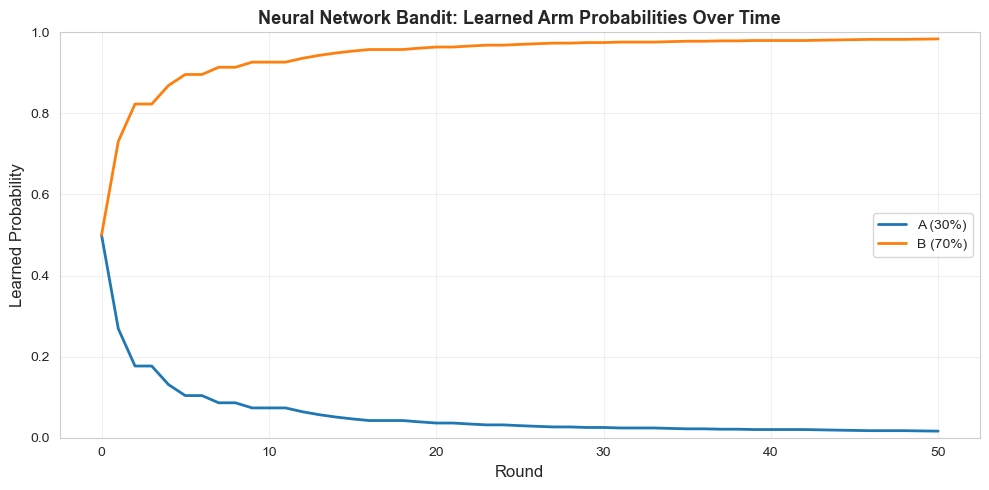

Final learned probabilities: [0.016 0.984]
True probabilities:          [0.3, 0.7]


In [147]:
# Train the NN bandit round by round — just like our other agents
prob_history = [agent.model(agent.dummy_input).numpy()[0].copy()]  # record initial 50/50
rewards_nn = []

for t in range(n_rounds_nn):
    arm = agent.choose()
    reward = bandit.pull(arm)
    agent.update(arm, reward)
    
    probs_learned = agent.model(agent.dummy_input).numpy()[0]
    prob_history.append(probs_learned.copy())
    rewards_nn.append(reward)

prob_history = np.array(prob_history)

# Plot how the network's arm probabilities evolve
fig, ax = plt.subplots(figsize=(10, 5))
arm_labels_nn = ['A (30%)', 'B (70%)']

for i, label in enumerate(arm_labels_nn):
    ax.plot(range(0, n_rounds_nn + 1), prob_history[:, i], label=label, linewidth=2)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Learned Probability', fontsize=12)
ax.set_title('Neural Network Bandit: Learned Arm Probabilities Over Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Final learned probabilities: {prob_history[-1].round(3)}")
print(f"True probabilities:          {probs_nn}")

### From bandits to deep reinforcement learning

The neural network above has **no inputs** so it learns a single "which arm is best?" answer.

But what if the best arm **depends on context**? For example:
- Which ad to show depends on the **user** (age, location, browsing history)
- Which treatment to prescribe depends on the **patient** (symptoms, lab results)
- Which move to make depends on the **game state** (board position)

**Add inputs to the network:**

```
No inputs -> [Dense] -> softmax -> arm probabilities      (what we just built)
User features -> [hidden layers] -> softmax -> arm probs  (contextual bandit / deep Q-learning)
```

This is the core idea behind:
- **Contextual bandits**: the reward of each arm depends on context (user features)
- **Deep Q-Networks (DQN)**: a neural network learns Q-values for each action given a state
- **Policy gradient methods**: a network directly outputs action probabilities

Combine this with epsilon-greedy exploration, and you have a simple **deep reinforcement learning** agent:
1. Observe the state (user features, game board, ...)
2. Feed it through a neural network → get action probabilities
3. With probability $\varepsilon$: explore (random action), else: exploit (best action)
4. Observe the reward, update the network via backpropagation

This is how systems like AlphaGo, ChatGPT (RLHF), and recommendation engines work — at a much larger scale, but the same fundamental ideas we covered today.

## Unified Framework: Multi-Armed Bandits

| What we learn | Objective | Optimization | Regularization | Hyperparameters |
|---------------|-----------|--------------|----------------|------------------|
| Which arm is best (unknown reward distributions) | Maximize cumulative reward (minimize regret) | Sequential: choose arm, observe, update | Exploration bonus prevents premature commitment | $\varepsilon$ (epsilon-greedy), $c$ (UCB) |

## Key Takeaways

1. **Exploration-exploitation trade-off**: You can't learn without trying, but trying costs you if the option is bad
2. **Time horizon matters**: Short horizons favor exploitation; long horizons reward exploration
3. **Non-stationarity requires continuous exploration**: If the world changes, past data becomes misleading
4. **UCB is principled**: "Optimism in the face of uncertainty" — explore what you're unsure about, not randomly
5. **Bandits are everywhere**: A/B testing, recommendations, hyperparameter tuning — anytime you choose among uncertain options